# H&M Customer Preference and Product Ranking

**Owner:** Binara  
**Module:** CCS4310 – Deep Learning  
**Project:** Explainable-Fashion-Design-AI

This notebook reads the preprocessing outputs from disk, compares popularity and practical preference models, and evaluates recommendation lists with ranking metrics. Development results are not final project results. No SHAP workflow is implemented; explainability is owned by Dewmi.

**Experiment note:** NCF is not part of the current experiment because it is not implemented.

In [1]:
from pathlib import Path
import json
import sys
import time
import hashlib
from time import perf_counter
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

RANDOM_STATE=42
FAST_DEV_RUN=False
FINAL_EVALUATION=False
if FINAL_EVALUATION and FAST_DEV_RUN:
    raise ValueError("FINAL_EVALUATION requires FAST_DEV_RUN=False")
TOP_K=12
RECENT_POPULARITY_DAYS=30
CSV_CHUNKSIZE=100_000
EVAL_BATCH_ROWS=100_000
FAST_DEV_ROWS=25_000
MAX_NEGATIVE_TRAIN_ROWS=500_000
MAX_POSITIVE_TRAIN_ROWS=500_000
np.random.seed(RANDOM_STATE)
overall_started=perf_counter()


def root():
    for p in [Path.cwd().resolve(),*Path.cwd().resolve().parents]:
        if (p/'data/interim').is_dir() and (p/'requirements.txt').exists(): return p
    raise FileNotFoundError('Repository root not found.')

ROOT=root(); INTERIM=ROOT/'data/interim'; METRICS=ROOT/'outputs/metrics'; FIGURES=ROOT/'outputs/figures'; MODEL_DIR=ROOT/'models/preference'
for d in [METRICS,FIGURES,MODEL_DIR]: d.mkdir(parents=True,exist_ok=True)


def required(name):
    path = INTERIM / name
    if not path.exists():
        raise FileNotFoundError(f'Missing required input: {path}')
    return path


def csv_columns(name):
    return list(pd.read_csv(required(name), nrows=0).columns)


def load_dev_frame(name, time_column):
    frame = pd.read_csv(required(name), nrows=FAST_DEV_ROWS)
    required_columns = {'customer_id', 'article_id', 'target', time_column}
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f'{name} is missing required columns {sorted(missing)}; available columns are {list(frame.columns)}')
    frame[time_column] = pd.to_datetime(frame[time_column], errors='raise')
    return frame


def iter_csv_chunks(name, time_column, columns=None):
    usecols = columns if columns is not None else None
    for frame in pd.read_csv(required(name), chunksize=CSV_CHUNKSIZE, usecols=usecols):
        if time_column in frame.columns:
            frame[time_column] = pd.to_datetime(frame[time_column], errors='raise')
        yield frame


config = json.loads(required('hm_preference_feature_config.json').read_text(encoding='utf-8'))
time_column = config.get('time_column', 't_dat')
train_path_name = 'hm_preference_train.csv'
valid_path_name = 'hm_preference_validation.csv'
test_path_name = 'hm_preference_test.csv'
train_columns = csv_columns(train_path_name)
valid_columns = csv_columns(valid_path_name)
if FAST_DEV_RUN:
    train = load_dev_frame(train_path_name, time_column)
    valid = load_dev_frame(valid_path_name, time_column)
else:
    train = None
    valid = None

test = None
print('Using existing shared repository .venv / selected project kernel:',sys.executable)
print('Run mode:', 'fast_dev' if FAST_DEV_RUN else ('full_final' if FINAL_EVALUATION else 'full_validation'))
if FAST_DEV_RUN: print(f'DEVELOPMENT ONLY: reproducible first {FAST_DEV_ROWS:,} rows per split; full files are not loaded.')
print('Configured time column:', time_column)
print('Input columns loaded from headers only:', len(train_columns), len(valid_columns))


Using existing shared repository .venv / selected project kernel: d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Scripts\python.exe
Run mode: full_validation
Configured time column: t_dat
Input columns loaded from headers only: 24 24


In [2]:
summary=json.loads(required('hm_preference_preprocessing_summary.json').read_text(encoding='utf-8'))
if 'date_ranges' not in summary or not all(k in summary['date_ranges'] for k in ['train', 'validation', 'test']):
    raise ValueError("Preprocessing summary is missing 'date_ranges' for train/validation/test. Run 04_hm_preprocessing.ipynb first.")
for frame_name, columns in [('train', train_columns), ('validation', valid_columns)]:
    required_columns={'customer_id','article_id','target',time_column}
    missing=required_columns.difference(columns)
    if missing:
        raise ValueError(f'{frame_name} is missing columns {sorted(missing)}; available columns are {columns}')
print('Train date range:',summary['date_ranges']['train'])
print('Validation date range:',summary['date_ranges']['validation'])
print('Test date range:',summary['date_ranges']['test'])
print('Recent popularity window:',RECENT_POPULARITY_DAYS,'days before each history cutoff')
assert not any(c in config['numerical_features'] for c in config['identifier_columns'])
assert 'price' not in config['numerical_features'], 'Current transaction price must not be a model feature.'


Train date range: ['2018-09-20 00:00:00', '2020-02-14 00:00:00']
Validation date range: ['2020-02-15 00:00:00', '2020-06-03 00:00:00']
Test date range: ['2020-06-04 00:00:00', '2020-09-22 00:00:00']
Recent popularity window: 30 days before each history cutoff


In [3]:
def _metric_for_customer(raw, score_col='score', k=TOP_K):
    ranked = raw.sort_values([score_col, 'article_id'], ascending=[False, True], kind='mergesort').drop_duplicates('article_id')
    relevant = set(ranked.loc[ranked.target.eq(1), 'article_id'])
    if not relevant:
        return None, len(ranked)
    top = ranked.head(k)
    hits = 0
    precision_sum = 0.0
    dcg = 0.0
    for rank, row in enumerate(top.itertuples(index=False), start=1):
        rel = int(getattr(row, 'target', 0) == 1)
        if rel:
            hits += 1
            precision_sum += hits / rank
            dcg += 1 / np.log2(rank + 1)
    denominator = min(len(relevant), k)
    ap = precision_sum / denominator
    recall = hits / len(relevant)
    idcg = sum(1 / np.log2(rank + 1) for rank in range(1, denominator + 1))
    return (ap, recall, dcg / idcg if idcg else 0.0), len(ranked)


def _empty_metric_state():
    return {'aps': [], 'recalls': [], 'ndcgs': [], 'candidate_sizes': []}


def _add_metric(state, customer_frame, score_col):
    values, candidate_size = _metric_for_customer(customer_frame, score_col=score_col)
    state['candidate_sizes'].append(candidate_size)
    if values is not None:
        ap, recall, ndcg = values
        state['aps'].append(ap)
        state['recalls'].append(recall)
        state['ndcgs'].append(ndcg)


def _finish_metrics(state):
    sizes = np.asarray(state['candidate_sizes'], dtype=float)
    if len(sizes):
        print(f"Candidate pool stats: median={np.median(sizes):.1f}, min={sizes.min():.1f}, max={sizes.max():.1f}")
        assert (sizes > TOP_K).any(), 'Candidate pool must be larger than TOP_K for ranking evaluation.'
    return {'MAP@12': float(np.mean(state['aps'])) if state['aps'] else 0.0,
            'Recall@12': float(np.mean(state['recalls'])) if state['recalls'] else 0.0,
            'NDCG@12': float(np.mean(state['ndcgs'])) if state['ndcgs'] else 0.0}


def customer_batches(name, time_column, columns=None, batch_rows=EVAL_BATCH_ROWS):
    """Yield bounded batches containing only complete customers."""
    if name is None:
        source = [valid]
    else:
        source = iter_csv_chunks(name, time_column, columns)
    pending_customer = None
    pending_id = None
    batch = []
    batch_size = 0
    for chunk in source:
        for cid, group in chunk.groupby('customer_id', sort=False):
            if pending_customer is not None and cid != pending_id:
                batch.append(pending_customer)
                batch_size += len(pending_customer)
                pending_customer = None
                if batch_size >= batch_rows:
                    yield pd.concat(batch, ignore_index=True)
                    batch = []
                    batch_size = 0
            pending_customer = group if pending_customer is None else pd.concat([pending_customer, group], ignore_index=True)
            pending_id = cid
    if pending_customer is not None:
        batch.append(pending_customer)
    if batch:
        yield pd.concat(batch, ignore_index=True)


def popularity_scores(frame, recent=False):
    column = 'recent_article_popularity' if recent else 'historical_article_popularity'
    frame['score'] = pd.to_numeric(frame[column], errors='coerce').fillna(0.0)
    return frame


def category_scores(frame):
    preferred = frame.get('preferred_category', pd.Series('UNKNOWN', index=frame.index)).fillna('UNKNOWN').astype(str)
    category = frame.get('product_group_name', pd.Series('UNKNOWN', index=frame.index)).fillna('UNKNOWN').astype(str)
    category_match = (preferred == category).astype(float)
    popularity = pd.to_numeric(frame['recent_article_popularity'], errors='coerce').fillna(0.0).clip(lower=0.0)
    frame['score'] = 2.0 * category_match + popularity / (1.0 + popularity)
    return frame


def score_evaluation_batch(frame, models, feature_cols, performance):
    """Vectorize baselines and make exactly one prediction call per ML model."""
    score_columns = {}
    for name, model in models.items():
        score_col = f'__score_{name.replace(" ", "_")}'
        if model is None:
            baseline_started=perf_counter()
            if name == 'Global Popularity':
                frame[score_col] = pd.to_numeric(frame['historical_article_popularity'], errors='coerce').fillna(0.0)
            elif name == 'Recent Popularity':
                frame[score_col] = pd.to_numeric(frame['recent_article_popularity'], errors='coerce').fillna(0.0)
            elif name == 'Category Preference':
                preferred = frame.get('preferred_category', pd.Series('UNKNOWN', index=frame.index)).fillna('UNKNOWN').astype(str)
                category = frame.get('product_group_name', pd.Series('UNKNOWN', index=frame.index)).fillna('UNKNOWN').astype(str)
                category_match = (preferred == category).astype(float)
                popularity = pd.to_numeric(frame['recent_article_popularity'], errors='coerce').fillna(0.0).clip(lower=0.0)
                frame[score_col] = 2.0 * category_match + popularity / (1.0 + popularity)
            performance['baseline_scoring_time'] += perf_counter()-baseline_started
        else:
            prediction_started=perf_counter()
            frame[score_col] = model.predict_proba(frame[feature_cols])[:, 1]
            elapsed=perf_counter()-prediction_started
            if name == 'Logistic Regression':
                performance['logistic_prediction_time'] += elapsed
            elif name == 'LightGBM':
                performance['lightgbm_prediction_time'] += elapsed
        score_columns[name] = score_col
    return score_columns


def evaluate_all_streams(split_name, file_name, models, feature_cols=None):
    """Evaluate every model in one pass using bounded batches of complete customers."""
    started=perf_counter()
    states={name:_empty_metric_state() for name in models}
    available=set(valid_columns if file_name is None else csv_columns(file_name))
    wanted=['customer_id','article_id','target',time_column]+(feature_cols or [])+['historical_article_popularity','recent_article_popularity','preferred_category','product_group_name']
    columns=[c for c in dict.fromkeys(wanted) if c in available]
    performance={'rows_processed':0,'customers_processed':0,'batches_processed':0,'csv_loading_time':0.0,
                 'baseline_scoring_time':0.0,'logistic_prediction_time':0.0,'lightgbm_prediction_time':0.0,
                 'ranking_metric_time':0.0}
    progress=tqdm(desc=f'{split_name} customers',unit='customer')
    batch_iterator=iter(customer_batches(file_name,time_column,columns))
    try:
        while True:
            load_started=perf_counter()
            try:
                batch=next(batch_iterator)
            except StopIteration:
                break
            performance['csv_loading_time'] += perf_counter()-load_started
            performance['batches_processed'] += 1
            score_columns=score_evaluation_batch(batch,models,feature_cols,performance)
            metric_started=perf_counter()
            for customer_id, customer_frame in batch.groupby('customer_id',sort=False):
                del customer_id
                for name, score_col in score_columns.items():
                    _add_metric(states[name],customer_frame,score_col)
            performance['ranking_metric_time'] += perf_counter()-metric_started
            performance['rows_processed'] += len(batch)
            batch_customers=batch['customer_id'].nunique()
            performance['customers_processed'] += batch_customers
            progress.update(batch_customers)
            progress.set_postfix(batches=performance['batches_processed'],rows=f"{performance['rows_processed']:,}")
            del score_columns, batch
    finally:
        progress.close()
    elapsed=perf_counter()-started
    performance['elapsed']=elapsed
    performance['rows_per_second']=performance['rows_processed']/elapsed if elapsed else 0.0
    performance['customers_per_second']=performance['customers_processed']/elapsed if elapsed else 0.0
    results={name:_finish_metrics(state) for name,state in states.items()}
    print(f'\n{split_name} performance summary')
    print('-'*32)
    print(f"Rows processed: {performance['rows_processed']:,}")
    print(f"Customers processed: {performance['customers_processed']:,}")
    print(f"Batches processed: {performance['batches_processed']:,}")
    print(f"Total elapsed: {elapsed:.1f} sec")
    print(f"Average rows/sec: {performance['rows_per_second']:,.1f}")
    print(f"Average customers/sec: {performance['customers_per_second']:,.1f}")
    print(f"CSV/data loading time: {performance['csv_loading_time']:.1f} sec")
    print(f"Baseline scoring time: {performance['baseline_scoring_time']:.1f} sec")
    print(f"Logistic Regression prediction time: {performance['logistic_prediction_time']:.1f} sec")
    print(f"LightGBM prediction time: {performance['lightgbm_prediction_time']:.1f} sec")
    print(f"Ranking metric calculation time: {performance['ranking_metric_time']:.1f} sec")
    return results, performance


In [4]:
# [1/4] Prepare the bounded ML training sample.
# Fit transformations on TRAIN data only. Only ML classifier fitting uses the bounded,
# deterministic resource-safe sample; full validation/test still evaluate every row.
sample_started=perf_counter()
leakage={'customer_id','article_id','target','split',time_column,'sales_channel_id','price'}
feature_cols=[c for c in train_columns if c not in leakage]
cat=[c for c in config['categorical_features'] if c in feature_cols]
num=[c for c in config['numerical_features'] if c in feature_cols]


def make_pipeline(classifier):
    pre=ColumnTransformer([
        ('num',SimpleImputer(strategy='median'),num),
        ('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat)
    ],remainder='drop')
    return Pipeline([('preprocess',pre),('classifier',classifier)])


def retain_smallest_hash(current, incoming, limit):
    if incoming.empty:
        return current
    incoming=incoming.copy()
    incoming['_stable_hash']=pd.util.hash_pandas_object(incoming[['customer_id','article_id']], index=False).to_numpy(dtype='uint64')
    combined=incoming if current is None or current.empty else pd.concat([current,incoming],ignore_index=True)
    return combined.nsmallest(limit,'_stable_hash',keep='first').reset_index(drop=True)


def prepare_training_frame():
    total=positive_count=negative_count=0
    retained_positive=None
    retained_negative=None
    chunks=[train] if FAST_DEV_RUN else iter_csv_chunks(train_path_name,time_column)
    training_progress=tqdm(chunks,desc='Training chunks',unit='chunk')
    try:
        for chunk in training_progress:
            total += len(chunk)
            positive=chunk[chunk.target.eq(1)]
            negative=chunk[chunk.target.eq(0)]
            positive_count += len(positive)
            negative_count += len(negative)
            retained_positive=retain_smallest_hash(retained_positive,positive,MAX_POSITIVE_TRAIN_ROWS)
            retained_negative=retain_smallest_hash(retained_negative,negative,MAX_NEGATIVE_TRAIN_ROWS)
            training_progress.set_postfix(chunks=training_progress.n,rows=f'{total:,}',positive=f'{positive_count:,}',negative=f'{negative_count:,}',positive_retained=len(retained_positive) if retained_positive is not None else 0,negative_retained=len(retained_negative) if retained_negative is not None else 0)
    finally:
        training_progress.close()
    selected=[frame.drop(columns='_stable_hash') for frame in [retained_positive,retained_negative] if frame is not None and not frame.empty]
    if not selected:
        raise ValueError('No training rows were retained for ML fitting.')
    sampled=pd.concat(selected,ignore_index=True)
    return sampled,total,positive_count,negative_count,len(retained_positive) if retained_positive is not None else 0,len(retained_negative) if retained_negative is not None else 0


train_fit,train_rows_available,train_positive_rows,train_negative_rows,train_positive_rows_used,train_negative_rows_used=prepare_training_frame()
train_rows_used=len(train_fit)
sample_elapsed=perf_counter()-sample_started
print(f'Training data prepared in {sample_elapsed:.1f}s')
print(f'Total training rows available: {train_rows_available:,}')
print(f'Total positive rows available: {train_positive_rows:,}')
print(f'Total negative rows available: {train_negative_rows:,}')
print(f'Positive rows retained for ML training: {train_positive_rows_used:,} (limit={MAX_POSITIVE_TRAIN_ROWS:,})')
print(f'Negative rows retained for ML training: {train_negative_rows_used:,} (limit={MAX_NEGATIVE_TRAIN_ROWS:,})')
print(f'Total ML training rows used: {train_rows_used:,}')
if train_positive_rows>MAX_POSITIVE_TRAIN_ROWS or train_negative_rows>MAX_NEGATIVE_TRAIN_ROWS:
    print('RESOURCE-SAFE TRAINING: only ML classifier fitting uses the bounded deterministic sample; no full training-row claim is made.')

# [2/4] Train the preference models.
print('[2/4] Training preference models...')
logistic_training_elapsed=0.0
lightgbm_training_elapsed=0.0
candidate_pipelines={}
if train_fit.target.nunique()>1 and feature_cols:
    try:
        print(f'Logistic Regression training started ({train_rows_used:,} rows)...')
        model_started=perf_counter()
        logistic=make_pipeline(LogisticRegression(max_iter=250,random_state=RANDOM_STATE,class_weight='balanced'))
        logistic.fit(train_fit[feature_cols],train_fit.target.astype(int))
        logistic_training_elapsed=perf_counter()-model_started
        candidate_pipelines['Logistic Regression']=logistic
        print(f'Logistic Regression completed in {logistic_training_elapsed:.1f} sec')
    except Exception as exc:
        print('Logistic Regression skipped:',exc)
else:
    print('Logistic Regression skipped: training data has fewer than two target classes or no usable features.')

try:
    from lightgbm import LGBMClassifier
    print(f'LightGBM training started ({train_rows_used:,} rows)...')
    model_started=perf_counter()
    lightgbm_model=make_pipeline(LGBMClassifier(n_estimators=120,learning_rate=0.05,num_leaves=31,random_state=RANDOM_STATE,verbosity=-1))
    lightgbm_model.fit(train_fit[feature_cols],train_fit.target.astype(int))
    lightgbm_training_elapsed=perf_counter()-model_started
    candidate_pipelines['LightGBM']=lightgbm_model
    print(f'LightGBM completed in {lightgbm_training_elapsed:.1f} sec')
except ImportError:
    print('LightGBM is not installed in the existing shared project .venv environment; this optional model will be skipped.')
except Exception as exc:
    print('LightGBM skipped:',exc)

# [3/4] Evaluate every model in one streaming validation pass.
print('[3/4] Full validation evaluation...')
models_to_evaluate={'Global Popularity':None,'Recent Popularity':None,'Category Preference':None}
models_to_evaluate.update(candidate_pipelines)
validation_started=perf_counter()
validation_scores,validation_performance=evaluate_all_streams('Validation',None if FAST_DEV_RUN else valid_path_name,models_to_evaluate,feature_cols)
validation_elapsed=perf_counter()-validation_started
validation_results=pd.DataFrame([
    {'model':name,'run_type':'fast_dev' if FAST_DEV_RUN else 'full_validation','validation_MAP@12':metrics['MAP@12'],'validation_Recall@K':metrics['Recall@12'],'validation_NDCG@K':metrics['NDCG@12']}
    for name,metrics in validation_scores.items()
])
if validation_results.empty:
    raise ValueError('No validation results were produced; cannot select a customer preference model.')
winner_row=validation_results.sort_values(['validation_MAP@12','validation_Recall@K','validation_NDCG@K'],ascending=[False,False,False]).iloc[0]
winner=str(winner_row['model'])
selection_metric='validation_MAP@12'
display(validation_results)
validation_results.to_csv(METRICS/('customer_preference_model_results_dev.csv' if FAST_DEV_RUN else 'customer_preference_model_results.csv'),index=False)


Training chunks: 0chunk [00:00, ?chunk/s]

Training data prepared in 799.5s
Total training rows available: 60,719,724
Total positive rows available: 20,239,908
Total negative rows available: 40,479,816
Positive rows retained for ML training: 500,000 (limit=500,000)
Negative rows retained for ML training: 500,000 (limit=500,000)
Total ML training rows used: 1,000,000
RESOURCE-SAFE TRAINING: only ML classifier fitting uses the bounded deterministic sample; no full training-row claim is made.
[2/4] Training preference models...
Logistic Regression training started (1,000,000 rows)...


d:\Deep Learning\Project\GITHUB\Explainable-Fashion-Design-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 250 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=250).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression completed in 32.9 sec
LightGBM training started (1,000,000 rows)...
LightGBM completed in 12.8 sec
[3/4] Full validation evaluation...


Validation customers: 0customer [00:00, ?customer/s]

Candidate pool stats: median=34.0, min=31.0, max=275.0
Candidate pool stats: median=34.0, min=31.0, max=275.0
Candidate pool stats: median=34.0, min=31.0, max=275.0
Candidate pool stats: median=34.0, min=31.0, max=275.0
Candidate pool stats: median=34.0, min=31.0, max=275.0

Validation performance summary
--------------------------------
Rows processed: 20,261,622
Customers processed: 548,527
Batches processed: 203
Total elapsed: 13723.5 sec
Average rows/sec: 1,476.4
Average customers/sec: 40.0
CSV/data loading time: 282.2 sec
Baseline scoring time: 5.5 sec
Logistic Regression prediction time: 108.5 sec
LightGBM prediction time: 125.2 sec
Ranking metric calculation time: 13200.3 sec


,model,run_type,validation_MAP@12,validation_Recall@K,validation_NDCG@K
0,Global Popularity,full_validation,0.337994,0.512489,0.470798
1,Recent Popularity,full_validation,0.319494,0.404685,0.397034
2,Category Preference,full_validation,0.233240,0.373756,0.330505
3,Logistic Regression,full_validation,0.481463,0.695136,0.616810
4,LightGBM,full_validation,0.480055,0.662232,0.600887


In [5]:
test_evaluation_elapsed=0.0
if not FAST_DEV_RUN and FINAL_EVALUATION:
    # [4/4] Test is opened only after validation winner selection and evaluated in one customer-safe pass.
    print('[4/4] Final test evaluation...')
    test_started=perf_counter()
    final_models=list(dict.fromkeys([winner,'Global Popularity','Recent Popularity','Category Preference']+list(candidate_pipelines)))
    test_model_map={name:candidate_pipelines.get(name) for name in final_models}
    print('Starting final test scoring/evaluation after winner selection.')
    test_scores,test_performance=evaluate_all_streams('Test',test_path_name,test_model_map,feature_cols)
    test_evaluation_elapsed=perf_counter()-test_started
    test_results=pd.DataFrame([
        {'model':name,'run_type':'full_final','test_MAP@12':metrics['MAP@12'],'test_Recall@K':metrics['Recall@12'],'test_NDCG@K':metrics['NDCG@12']}
        for name,metrics in test_scores.items()
    ])
    display(test_results)
    test_results.to_csv(METRICS/'customer_preference_final_test_results.csv',index=False)

selected_artifact=candidate_pipelines.get(winner,{'model_type':winner,'note':'Serializable baseline configuration; no fitted ML model claimed.'})
if winner in {'Global Popularity','Recent Popularity','Category Preference'}:
    selected_artifact={'model_type':winner,'note':'Baseline recommendation policy; no fitted ML model was trained.'}
artifact_suffix='' if (not FAST_DEV_RUN and FINAL_EVALUATION) else '_dev'
joblib.dump(selected_artifact,MODEL_DIR/f'best_customer_preference_model{artifact_suffix}.joblib')
run_type='fast_dev' if FAST_DEV_RUN else ('full_final' if FINAL_EVALUATION else 'full_validation')
model_config={'selected_model':winner,'selection_metric':selection_metric,'TOP_K':TOP_K,
              'recent_popularity_days':RECENT_POPULARITY_DAYS,'candidate_pool_policy':config['candidate_pool_policy'],
              'negative_sampling_policy':config['negative_sampling_policy'],'feature_columns':feature_cols,
              'run_type':run_type,'fast_dev_run':FAST_DEV_RUN,'final_evaluation':FINAL_EVALUATION,
              'training_rows_available':train_rows_available,'training_rows_used':train_rows_used,
              'training_positive_rows_available':train_positive_rows,'training_negative_rows_available':train_negative_rows,
              'training_positive_rows_used':train_positive_rows_used,'training_negative_rows_used':train_negative_rows_used,
              'max_positive_train_rows':MAX_POSITIVE_TRAIN_ROWS,'max_negative_train_rows':MAX_NEGATIVE_TRAIN_ROWS,
              'leakage_exclusions':sorted(leakage)}
(MODEL_DIR/f'customer_preference_model_config{artifact_suffix}.json').write_text(json.dumps(model_config,indent=2),encoding='utf-8')

print('\nOverall runtime summary')
print('-'*24)
print(f'ML training sample preparation: {sample_elapsed:.1f} sec')
print(f'Logistic Regression training: {logistic_training_elapsed:.1f} sec')
print(f'LightGBM training: {lightgbm_training_elapsed:.1f} sec')
print(f'Validation evaluation: {validation_elapsed:.1f} sec')
if not FAST_DEV_RUN and FINAL_EVALUATION:
    print(f'Test evaluation: {test_evaluation_elapsed:.1f} sec')
print(f'Total runtime: {perf_counter()-overall_started:.1f} sec')



Overall runtime summary
------------------------
ML training sample preparation: 799.5 sec
Logistic Regression training: 32.9 sec
LightGBM training: 12.8 sec
Validation evaluation: 13724.9 sec
Total runtime: 14570.7 sec


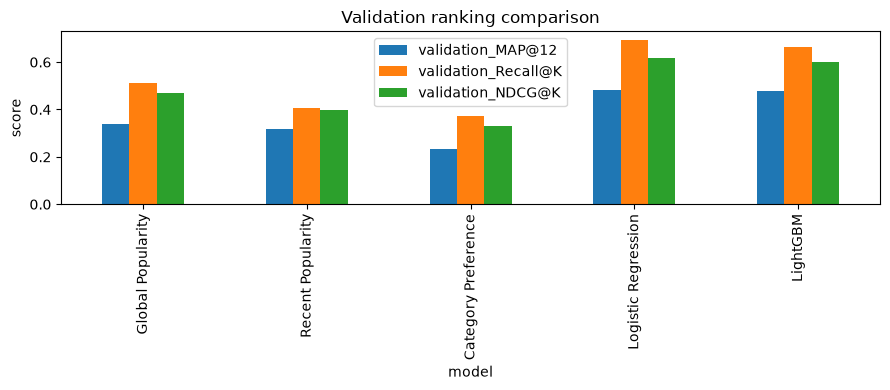

Validation winner selected by validation_MAP@12: Logistic Regression
Cold start: new customers fall back to recent/global popularity; new products use available article metadata. No sensitive traits or visual embeddings are inferred.
Limitations: FAST_DEV_RUN uses a capped reproducible transaction subset; full validation evaluates every validation row in customer-safe chunks.


In [6]:
fig,ax=plt.subplots(figsize=(9,4)); plot_df=validation_results.set_index('model')[['validation_MAP@12','validation_Recall@K','validation_NDCG@K']]; plot_df.plot.bar(ax=ax,title='Validation ranking comparison'); ax.set_ylabel('score'); plt.tight_layout(); plt.savefig(FIGURES/('binara_preference_validation_metrics_dev.png' if FAST_DEV_RUN else 'binara_preference_validation_metrics.png'),dpi=120); plt.show(); plt.close()
print(f'Validation winner selected by {selection_metric}: {winner}')
if not FAST_DEV_RUN and FINAL_EVALUATION:
    print('Test comparisons were run only after winner selection; no test result selected the winner.')
print('Cold start: new customers fall back to recent/global popularity; new products use available article metadata. No sensitive traits or visual embeddings are inferred.')
print('Limitations: FAST_DEV_RUN uses a capped reproducible transaction subset; full validation evaluates every validation row in customer-safe chunks.')
